# 🔬 Notebook 00: Foundry Project Bootstrap & Investigation Conversation

In this notebook, we bootstrap an Microsoft Foundry project connection and run our first SOC triage workflow end-to-end. It's 2:32 PM on a Tuesday. A high-severity alert just fired, and we need a fast, structured first-pass investigation.

We'll create a SOC triage agent, generate a triage note from a response, visualize entity risk, and persist an `InvestigationRecord` for the next notebook.

In [1]:
import nest_asyncio
nest_asyncio.apply()

import sys, os, json
sys.path.insert(0, os.path.abspath("../src"))
from soc_workshop.settings import get_settings, require
from soc_workshop.clients import get_project_client, configure_tracing
from soc_workshop.incident_schema import Alert, Entity, InvestigationRecord, TimelineEvent
from azure.ai.projects.models import PromptAgentDefinition

import re
from dataclasses import asdict

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

settings = get_settings()
configure_tracing()
require(settings, "project_endpoint", "model_deployment")
project_client = get_project_client(settings)
openai_client = project_client.get_openai_client()

In [2]:
with open("../data/alerts.json", "r", encoding="utf-8") as f:
    alerts_raw = json.load(f)

alerts = [Alert.from_dict(item.copy()) for item in alerts_raw]
primary_alert = next(a for a in alerts if a.alert_id == "ALERT-2025-001")

alerts_df = pd.DataFrame([
    {
        "alert_id": a.alert_id,
        "title": a.title,
        "severity": a.severity,
        "source": a.source,
        "timestamp": a.timestamp,
        "techniques": ", ".join(a.techniques),
        "entities": len(a.entities),
    }
    for a in alerts
])

display(alerts_df.sort_values(["timestamp", "severity"], ascending=[True, True]).reset_index(drop=True))
display(Markdown(f"**Primary Alert Selected:** `{primary_alert.alert_id}` — {primary_alert.title}"))

,alert_id,title,severity,source,timestamp,techniques,entities
0,ALERT-2025-002,Anomalous sign-in from TOR exit node,High,Microsoft Entra ID Protection,2025-03-07T03:18:45Z,T1078,2
1,ALERT-2025-004,Credential harvesting phishing email detected,Medium,Microsoft Defender for Office 365,2025-03-07T09:45:00Z,T1566.002,3
2,ALERT-2025-001,Suspicious PowerShell execution with encoded c...,High,Microsoft Defender for Endpoint,2025-03-07T14:32:11Z,"T1059.001, T1071.001",4
3,ALERT-2025-006,Data exfiltration to cloud storage service,High,Microsoft Defender for Cloud Apps,2025-03-07T14:48:00Z,T1567.002,3
4,ALERT-2025-005,Lateral movement via PsExec to domain controller,Critical,Microsoft Defender for Identity,2025-03-07T14:55:02Z,"T1570, T1078.002",3
5,ALERT-2025-003,Mass file encryption detected on network share,Critical,Microsoft Defender for Endpoint,2025-03-07T15:01:33Z,T1486,3


**Primary Alert Selected:** `ALERT-2025-001` — Suspicious PowerShell execution with encoded command

## Creating our first SOC agent

We'll configure a Tier-1 analyst agent with explicit triage responsibilities aligned to SOC practice. The prompt emphasizes MITRE ATT&CK mapping, severity rationale, and immediate containment-oriented actions.

In [ ]:
agent_instructions = """You are a Tier-1 SOC analyst handling active security triage in an enterprise environment.

Your tasks for each alert:
1) Analyze the alert telemetry and context for likely malicious behavior.
2) Assess severity with clear rationale (business impact + technical confidence).
3) Identify key entities (host, user, IP, file hash, domains) and prioritize by risk.
4) Form an initial hypothesis about attacker objective and stage in the kill chain.
5) Map observed behavior to MITRE ATT&CK tactics/techniques where relevant.
6) Recommend immediate SOC actions (containment, validation, telemetry pivots).
7) Assign a confidence score from 0-100 and justify uncertainty.

Output format (Markdown):
## Initial Hypothesis
## Severity Assessment
## Key Entities
## Recommended Next Steps
## Confidence Score
Keep the note concise, operational, and action-oriented."""

agent = project_client.agents.create_version(
    agent_name="soc-00-triage-analyst",
    definition=PromptAgentDefinition(
        model=settings.model_deployment,
        instructions=agent_instructions,
    ),
)

print(f"Created agent: {agent.name}, version: {agent.version}")

Created agent: soc-triage-analyst, version: 1


In [5]:
alert_payload = json.dumps(asdict(primary_alert), indent=2)
user_message = (
    "It's 2:32 PM on a Tuesday. A high-severity alert just fired and this is our first triage pass. "
    "Review the JSON and produce a SOC triage note with hypothesis, severity assessment, key entities, "
    "recommended next steps, and a confidence score.\n\n"
    f"```json\n{alert_payload}\n```"
)

response = openai_client.responses.create(
    input=user_message,
    model=settings.model_deployment,
    extra_body={
        "agent_reference": {
            "name": agent.name,
            "type": "agent_reference",
        }
    },
)
print(f"Response ID: {response.id}")
print(f"Status: {response.status}")

Response ID: resp_088611d1abe89f940069adedfe95b08195a7afc312a5918322
Status: completed


In [6]:
triage_note = response.output_text

display(Markdown("### 📝 Triage Note\n"))
display(Markdown(triage_note))

### 📝 Triage Note


## Initial Hypothesis

An attacker is leveraging PowerShell on a finance department workstation (WKS-FIN-PC04) to execute an encoded command that downloads a second-stage payload from a known Cobalt Strike command-and-control (C2) IP (198.51.100.23). This activity is consistent with Cobalt Strike stager deployment, likely as part of an initial access or execution phase, following successful delivery via phishing, drive-by, or malicious document.

## Severity Assessment

**High Severity.**  
- **Business Impact:** The alert involves a privileged workstation in the finance department (high-value target), with user (jdoe@contoso.com) likely having access to sensitive data.
- **Technical Confidence:** Strong context—PowerShell encoded payload, known C2 infrastructure, and file hash mapped to Cobalt Strike Beacon.
- Likely part of hands-on-keyboard or automated post-compromise activity; high risk for lateral movement, credential theft, or data exfiltration if not contained.

## Key Entities

- **Host:** WKS-FIN-PC04 *(High Risk: 85, finance-dept)*
- **User:** jdoe@contoso.com *(Risk: 70, finance-team)*
- **IP (C2):** 198.51.100.23 *(Very High Risk: 92, known-c2, cobalt-strike)*
- **File Hash:** a1b2c3... *(Very High Risk: 95, cobalt-strike-beacon)*

**Priority:**  
1. Host (potentially compromised, finance data risk)  
2. C2 IP (active remote control/second-stage risk)  
3. File hash (malicious payload present/active)  
4. User (credential/insider risk if compromised)

## Recommended Next Steps

**Containment:**
- Isolate WKS-FIN-PC04 from the network immediately to prevent propagation and C2 callbacks.
- Block outbound communication to 198.51.100.23 at the firewall and proxy level.

**Validation/Telemetry:**
- Pull volatile system and memory data from affected device for forensic preservation.
- Review PowerShell logs and process tree for additional suspicious activity.
- Search environment for additional connections to 198.51.100.23 and for presence of the file hash on other assets.
- Validate recent activity for jdoe@contoso.com in identity logs (lateral movement, privilege escalation).

**Communication:**
- Notify finance security liaison and incident response team for further escalation and advice on business continuity actions.

## Confidence Score

**95/100**

**Justification:**  
Extensive corroborating evidence supports malicious activity (encoded PowerShell, known C2, Cobalt Strike detection, high-value target), but this is a first triage pass—memory analysis and broader environment checks could adjust scope or attribution. The only uncertainty is root cause (phishing, RDP compromise, etc.) and complete extent of compromise.

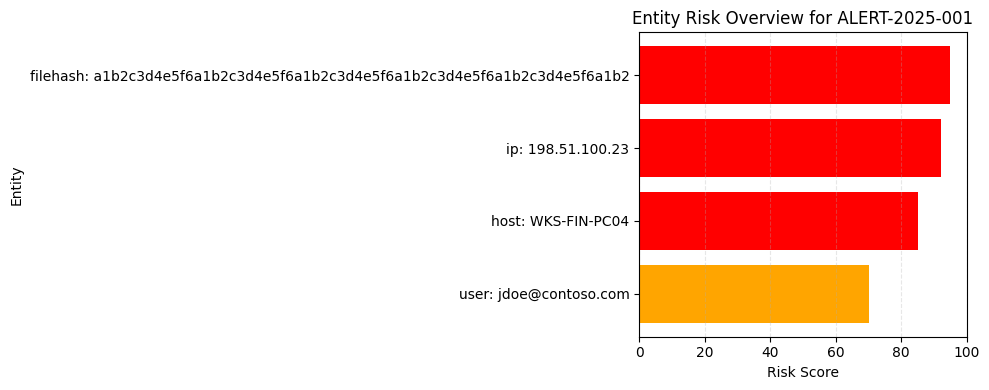

,entity,risk_score,risk_level
0,filehash: a1b2c3d4e5f6a1b2c3d4e5f6a1b2c3d4e5f6...,95,Critical
1,ip: 198.51.100.23,92,Critical
2,host: WKS-FIN-PC04,85,High
3,user: jdoe@contoso.com,70,Medium


In [7]:
entity_df = pd.DataFrame([
    {
        "entity": f"{e.entity_type}: {e.value}",
        "risk_score": int(e.risk_score) if e.risk_score is not None else 0
    }
    for e in primary_alert.entities
])

def risk_level(score):
    if score >= 90:
        return "Critical"
    if score >= 75:
        return "High"
    if score >= 50:
        return "Medium"
    return "Low"

entity_df["risk_level"] = entity_df["risk_score"].apply(risk_level)
color_map = {"Critical": "red", "High": "red", "Medium": "orange", "Low": "green"}
plot_df = entity_df.sort_values("risk_score", ascending=True)

plt.figure(figsize=(10, 4))
plt.barh(plot_df["entity"], plot_df["risk_score"], color=plot_df["risk_level"].map(color_map))
plt.xlabel("Risk Score")
plt.ylabel("Entity")
plt.title("Entity Risk Overview for ALERT-2025-001")
plt.xlim(0, 100)
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

display(entity_df.sort_values("risk_score", ascending=False).reset_index(drop=True))

In [8]:
# Get the body of a specific Markdown '##' section, stopping at the next section.
def _section(text, heading):
    pattern = rf"(?ims)^##\s*{re.escape(heading)}\s*$\n(.*?)(?=^##\s|\Z)"
    match = re.search(pattern, text)
    return match.group(1).strip() if match else ""

hypothesis = _section(triage_note, "Initial Hypothesis") or "Potential Cobalt Strike staging via encoded PowerShell execution on a finance workstation."
severity_assessment = _section(triage_note, "Severity Assessment")
recommended_steps_block = _section(triage_note, "Recommended Next Steps")
confidence_block = _section(triage_note, "Confidence Score")

step_lines = [
    re.sub(r"^[-*\d.\)\s]+", "", line).strip()
    for line in recommended_steps_block.splitlines()
    if line.strip()
]
recommended_actions = step_lines or [
    "Isolate WKS-FIN-PC04 from the network immediately.",
    "Block and investigate outbound traffic to 198.51.100.23.",
    "Acquire process tree and memory artifacts for PowerShell/beacon analysis."
]

confidence_match = re.search(r"(100|[1-9]?\d)", confidence_block)
confidence_pct = int(confidence_match.group(1)) if confidence_match else 70

investigation = InvestigationRecord(
    incident_id=primary_alert.alert_id,
    title=f"Investigation - {primary_alert.title}",
    alerts=[primary_alert],
    entities=primary_alert.entities,
    timeline=[
        TimelineEvent(
            timestamp=primary_alert.timestamp,
            event=f"Alert received: {primary_alert.title}",
            source=primary_alert.source,
            severity=primary_alert.severity.lower()
        ),
        TimelineEvent(
            timestamp=primary_alert.timestamp,
            event="Tier-1 triage note generated by SOC triage agent",
            source="azure-ai-foundry-agent",
            severity="info"
        )
    ],
    hypothesis=hypothesis,
    verdict=severity_assessment or "Escalate for containment and deeper investigation",
    confidence=confidence_pct / 100.0,
    recommended_actions=recommended_actions,
    thread_id=response.id,
    agent_ids=[f"{agent.name}:{agent.version}"],
)

with open("../data/investigation_00.json", "w", encoding="utf-8") as f:
    f.write(investigation.to_json(indent=2))

print("Saved InvestigationRecord to ../data/investigation_00.json")

Saved InvestigationRecord to ../data/investigation_00.json


### Summary of this notebook

The notebook walks through a full first-pass SOC triage flow. It loads alert data, picks a primary alert, and shows a quick table of available alerts. It then creates a Tier‑1 SOC agent with a structured prompt, sends the primary alert payload, and displays the generated triage note.

Next, it visualizes entity risk scores with a horizontal bar chart and a table, then parses the triage note into sections (hypothesis, severity, next steps, confidence). Finally, it builds an InvestigationRecord, saves it to a JSON file for downstream notebooks, and optionally shows how to clean up the agent.

### (Optional) clean up the agent

In [9]:
# optional action, uncomment 

# project_client.agents.delete_version(agent_name=agent.name, agent_version=agent.version)
# openai_client.close()
# print(f"Cleanup complete. Deleted agent: {agent.name} v{agent.version}")

## What's Next

In Notebook 01, we'll continue from `investigation_00.json`, enrich evidence, and correlate additional telemetry sources. The response trace and triage artifacts from this notebook become the starting context for deeper incident analysis.